# Example Core Scalar Surface

Canonical core-scalar example notebook for the `arb_core`, `acb_core`, `arf`, `acf`, `fmpr`, `fmpzi`, and `arb_fpwrap` public surfaces.

## Scope

This notebook is the canonical example surface for `example_core_scalar_surface`. It runs against the repo source tree through `/src`, shows direct public API usage, summarizes validation and benchmark status, and includes visual summaries.

In [1]:
import io
import json
import os
import re
import subprocess
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'arbplusjax').exists():
            return p
    raise RuntimeError(f'Could not locate repo root from: {start}')

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
os.chdir(REPO_ROOT)

PYTHON = os.getenv('ARBPLUSJAX_PYTHON', sys.executable)
JAX_MODE = os.getenv('JAX_MODE', 'cpu').strip().lower()
JAX_DTYPE = os.getenv('JAX_DTYPE', 'float64').strip().lower()
RUN_ENV = os.environ.copy()
RUN_ENV['PYTHONPATH'] = str(REPO_ROOT / 'src') + os.pathsep + RUN_ENV.get('PYTHONPATH', '')
if JAX_MODE == 'cpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cpu'
elif JAX_MODE == 'gpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cuda'
RUN_ENV['JAX_ENABLE_X64'] = '1' if JAX_DTYPE == 'float64' else '0'
EXAMPLE_INPUT_ROOT = REPO_ROOT / 'examples' / 'inputs' / 'example_core_scalar_surface'
EXAMPLE_OUTPUT_ROOT = REPO_ROOT / 'examples' / 'outputs' / 'example_core_scalar_surface'
EXAMPLE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def run(cmd: list[str], *, capture: bool = False):
    print('[cmd]', ' '.join(cmd))
    return subprocess.run(cmd, cwd=REPO_ROOT, env=RUN_ENV, text=True, capture_output=capture, check=True)


## Environment

The notebook reports interpreter, selected JAX mode, and the active backend/device view. Canonical retained execution in this repo state is CPU-oriented, but the notebook calling pattern remains CPU/GPU portable and explicitly parameterized for `float32` and `float64`.

In [2]:
SUPPORTED_JAX_MODES = ('cpu', 'gpu')
SUPPORTED_JAX_DTYPES = ('float32', 'float64')
if JAX_MODE not in SUPPORTED_JAX_MODES:
    raise ValueError(f'Unsupported JAX_MODE: {JAX_MODE}')
if JAX_DTYPE not in SUPPORTED_JAX_DTYPES:
    raise ValueError(f'Unsupported JAX_DTYPE: {JAX_DTYPE}')
print('python:', PYTHON)
print('jax_mode:', JAX_MODE)
print('jax_dtype:', JAX_DTYPE)
print('supported_jax_modes:', SUPPORTED_JAX_MODES)
print('supported_jax_dtypes:', SUPPORTED_JAX_DTYPES)
print('validation_slice:', 'cpu_current__gpu_portable_contract')
runtime = run([PYTHON, 'tools/check_jax_runtime.py'], capture=True)
print(runtime.stdout)
runtime_payload = json.loads(runtime.stdout)
(EXAMPLE_OUTPUT_ROOT / f'runtime_{JAX_MODE}.json').write_text(json.dumps(runtime_payload, indent=2) + '\n', encoding='utf-8')

python: /home/phili/miniforge3/envs/jax/bin/python
jax_mode: cpu
jax_dtype: float64
supported_jax_modes: ('cpu', 'gpu')
supported_jax_dtypes: ('float32', 'float64')
validation_slice: cpu_current__gpu_portable_contract
[cmd] /home/phili/miniforge3/envs/jax/bin/python tools/check_jax_runtime.py


{
  "platform": "cpu",
  "devices": [
    "TFRT_CPU_0"
  ],
  "jax_enable_x64": true,
  "env": {
    "JAX_PLATFORM_NAME": "",
    "XLA_PYTHON_CLIENT_PREALLOCATE": "",
    "XLA_PYTHON_CLIENT_MEM_FRACTION": "",
    "XLA_FLAGS": ""
  }
}



235

## Object/Input Construction

Construct representative real intervals, complex boxes, floating arrays, integer-interval arrays, and fpwrap point inputs.

In [3]:
import jax.numpy as jnp
from arbplusjax import acb_core, api, double_interval as di

real_interval = di.interval(jnp.array([0.2, 0.5, 1.0], dtype=jnp.float64), jnp.array([0.25, 0.6, 1.1], dtype=jnp.float64))
complex_box = acb_core.acb_box(
    di.interval(jnp.array([0.2, 0.4], dtype=jnp.float64), jnp.array([0.25, 0.5], dtype=jnp.float64)),
    di.interval(jnp.array([-0.2, 0.1], dtype=jnp.float64), jnp.array([-0.1, 0.2], dtype=jnp.float64)),
)
float_a = jnp.array([1.0, 2.0, 3.0], dtype=jnp.float32)
float_b = jnp.array([0.5, 1.5, 2.5], dtype=jnp.float32)
complex_a = jnp.array([1.0 + 0.5j, 2.0 - 0.25j], dtype=jnp.complex64)
int_interval_a = jnp.array([[1, 2], [3, 5], [8, 13]], dtype=jnp.int64)
int_interval_b = jnp.array([[2, 3], [5, 8], [13, 21]], dtype=jnp.int64)
fpwrap_real = jnp.array([0.1, 0.4, 0.9], dtype=jnp.float32)
display({'real_interval_shape': real_interval.shape, 'complex_box_shape': complex_box.shape})

{'real_interval_shape': (3, 2), 'complex_box_shape': (2, 4)}

## Direct Usage

Run the public API directly on representative core scalar families.

In [4]:
results = {
    'arb_exp_basic': api.eval_interval('arb_exp', real_interval, mode='basic', dtype='float64'),
    'acb_sin_basic': api.eval_interval('acb_sin', complex_box, mode='basic', dtype='float64'),
    'arf_add': api.eval_point('arf_add', float_a, float_b),
    'acf_mul': api.eval_point('acf_mul', complex_a, complex_a),
    'fmpr_mul': api.eval_point('fmpr_mul', float_a, float_b),
    'fmpzi_add': api.eval_point('fmpzi_add', int_interval_a, int_interval_b),
    'arb_fpwrap_double_exp': api.eval_point('arb_fpwrap_double_exp', fpwrap_real),
}
display(results)

{'arb_exp_basic': Array([[1.22140276, 1.28402542],
        [1.64872127, 1.8221188 ],
        [2.71828183, 3.00416602]], dtype=float64),
 'acb_sin_basic': Array([[ 0.22562102,  0.22562102, -0.14676805, -0.14676805],
        [ 0.43986808,  0.43986808,  0.13557414,  0.13557414]],      dtype=float64),
 'arf_add': Array([1.5, 3.5, 5.5], dtype=float32),
 'acf_mul': Array([0.75  +1.j, 3.9375-1.j], dtype=complex64),
 'fmpr_mul': Array([0.5, 3. , 7.5], dtype=float32),
 'fmpzi_add': Array([[ 3,  5],
        [ 8, 13],
        [21, 34]], dtype=int64),
 'arb_fpwrap_double_exp': Array([1.105171 , 1.4918246, 2.459603 ], dtype=float32)}

## Production Pattern

Production use should bind once, keep dtype stable, choose backend policy explicitly, and use padding or shape buckets when repeated calls would otherwise trigger shape churn. For helper scalar families, `bind_point_batch()` / `bind_point_batch_with_diagnostics()` are the main service-style entrypoints, and `choose_point_batch_policy()` plus `prewarm_core_point_kernels()` define the intended repeated-call policy.

In [5]:
service_real = jnp.linspace(0.1, 1.0, 7, dtype=jnp.float32)
service_complex = jnp.asarray([0.1 + 0.2j, 0.3 - 0.1j, 0.5 + 0.4j], dtype=jnp.complex64)
scalar_policy = api.choose_point_batch_policy(batch_size=service_real.shape[0], dtype='float32', backend='auto', shape_bucket_multiple=16, min_gpu_batch_size=64)
api.prewarm_core_point_kernels(names=('arf_add', 'acf_mul', 'arb_fpwrap_double_exp'), dtype='float32', backend='auto', batch_size=16, shape_bucket_multiple=16, min_gpu_batch_size=64)
arf_bound = api.bind_point_batch_with_diagnostics('arf_add', dtype='float32', shape_bucket_multiple=16, chunk_size=4, backend='auto', min_gpu_batch_size=64)
acf_bound = api.bind_point_batch_with_diagnostics('acf_mul', dtype='float32', shape_bucket_multiple=16, chunk_size=4, backend='auto', min_gpu_batch_size=64)
fpwrap_bound = api.bind_point_batch_with_diagnostics('arb_fpwrap_double_exp', dtype='float32', shape_bucket_multiple=16, backend='auto', min_gpu_batch_size=64)
arf_vals, arf_diag = arf_bound(service_real, service_real)
acf_vals, acf_diag = acf_bound(service_complex, service_complex)
fpwrap_vals, fpwrap_diag = fpwrap_bound(service_real)
service_results = {
    'scalar_policy': scalar_policy,
    'arf_bound': arf_vals,
    'arf_diag': arf_diag,
    'acf_bound': acf_vals,
    'acf_diag': acf_diag,
    'fpwrap_bound': fpwrap_vals,
    'fpwrap_diag': fpwrap_diag,
}
display(service_results)

{'scalar_policy': PointBatchPolicy(requested_backend='auto', chosen_backend='cpu', batch_size=7, dtype='float32', pad_to=None, shape_bucket_multiple=16, effective_pad_to=16, chunk_size=None, min_gpu_batch_size=64, prewarm=False),
 'arf_bound': Array([0.2      , 0.5      , 0.8      , 1.1      , 1.4000001, 1.7      ,
        2.       ], dtype=float32),
 'arf_diag': PointBatchCallDiagnostics(name='arf_add', requested_backend='auto', chosen_backend='cpu', batch_size=7, dtype='float32', pad_to=None, shape_bucket_multiple=16, effective_pad_to=16, chunk_size=4, jit_enabled=False, compiled_this_call=False, prewarmed=False),
 'acf_bound': Array([-0.03      +0.04j,  0.08000001-0.06j,  0.08999999+0.4j ],      dtype=complex64),
 'acf_diag': PointBatchCallDiagnostics(name='acf_mul', requested_backend='auto', chosen_backend='cpu', batch_size=3, dtype='float32', pad_to=None, shape_bucket_multiple=16, effective_pad_to=16, chunk_size=4, jit_enabled=False, compiled_this_call=False, prewarmed=False),
 'f

## Extending Benchmarks

To benchmark another scalar family, either add another existing benchmark entrypoint to the `bench_dir` loop below or extend the representative operations in `benchmark_core_scalar_service_api.py` / `benchmark_core_scalar_batch_padding.py` and rerun this notebook.

## Fast JAX Point Pattern

For the true compiled point path, use `api.bind_point_batch_jit(...)` or `api.bind_point_batch_jit_with_diagnostics(...)` with stable `dtype` and `pad_to` or `shape_bucket_multiple`. This is the API-level fast-JAX surface for repeated point evaluation, while the diagnostics layer makes the chosen backend and effective padded shape explicit.

In [6]:
import jax
fast_real = jnp.linspace(0.1, 1.2, 8, dtype=jnp.float32)
fast_bound = api.bind_point_batch_jit_with_diagnostics('arb_fpwrap_double_exp', dtype='float32', shape_bucket_multiple=8, backend='auto', min_gpu_batch_size=64)
fast_vals, fast_diag = fast_bound(fast_real)
fast_vmap = jax.vmap(lambda t: api.eval_point('arb_fpwrap_double_exp', t, dtype='float32'))(fast_real)
display({'jit_shape': fast_vals.shape, 'jit_dtype': fast_vals.dtype, 'jit_matches_vmap': bool(jnp.allclose(fast_vals, fast_vmap)), 'jit_diag': fast_diag})

{'jit_shape': (8,),
 'jit_dtype': dtype('float32'),
 'jit_matches_vmap': True,
 'jit_diag': PointBatchCallDiagnostics(name='arb_fpwrap_double_exp', requested_backend='auto', chosen_backend='cpu', batch_size=8, dtype='float32', pad_to=None, shape_bucket_multiple=8, effective_pad_to=8, chunk_size=None, jit_enabled=True, compiled_this_call=True, prewarmed=False)}

## AD Product Pattern

AD should be shown in both directions on the production-facing scalar surface: through the main value argument and through the family parameter. This section validates `arb_pow` over both `x` and `y` sweeps and plots the paired sensitivities.

,x,primal_x,grad_x,y,primal_y,grad_y
0,0.800000,0.855388,0.748464,0.200000,1.053874,0.276499
1,0.832258,0.879388,0.739640,0.232258,1.062831,0.278849
2,0.864516,0.903111,0.731250,0.264516,1.071864,0.281219
3,0.896774,0.926570,0.723258,0.296774,1.080974,0.283609
4,0.929032,0.949777,0.715630,0.329032,1.090162,0.286020


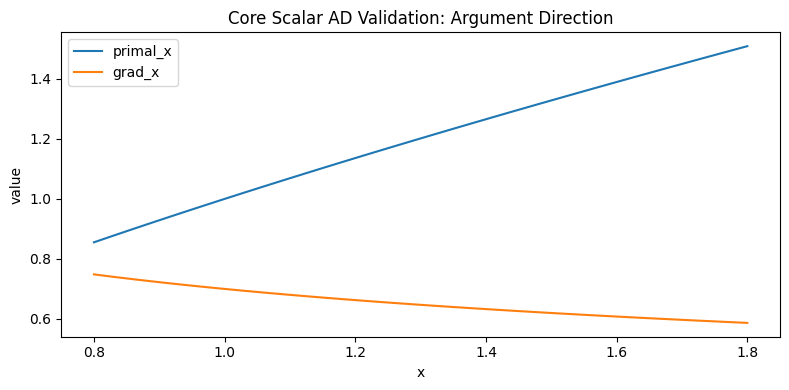

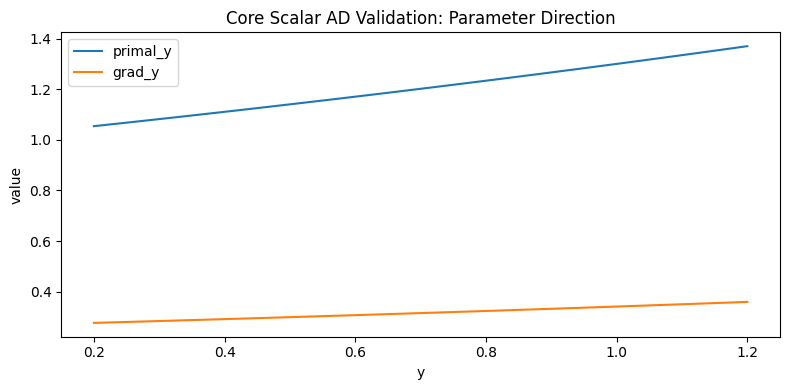

In [7]:
import jax
y_fixed = jnp.asarray(0.7, dtype=jnp.float32)
x_fixed = jnp.asarray(1.3, dtype=jnp.float32)
def scalar_loss_x(xv):
    return api.eval_point('arb_pow', xv, y_fixed, dtype='float32')
def scalar_loss_y(yv):
    return api.eval_point('arb_pow', x_fixed, yv, dtype='float32')
x_sweep = jnp.linspace(0.8, 1.8, 32, dtype=jnp.float32)
y_sweep = jnp.linspace(0.2, 1.2, 32, dtype=jnp.float32)
primal_x = jax.vmap(scalar_loss_x)(x_sweep)
grad_x = jax.vmap(jax.grad(scalar_loss_x))(x_sweep)
primal_y = jax.vmap(scalar_loss_y)(y_sweep)
grad_y = jax.vmap(jax.grad(scalar_loss_y))(y_sweep)
ad_df = pd.DataFrame({'x': np.asarray(x_sweep), 'primal_x': np.asarray(primal_x), 'grad_x': np.asarray(grad_x), 'y': np.asarray(y_sweep), 'primal_y': np.asarray(primal_y), 'grad_y': np.asarray(grad_y)})
display(ad_df.head())
ax = ad_df.plot(x='x', y=['primal_x', 'grad_x'], figsize=(8, 4), title='Core Scalar AD Validation: Argument Direction')
ax.set_ylabel('value')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'ad_validation_argument_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()
ax = ad_df.plot(x='y', y=['primal_y', 'grad_y'], figsize=(8, 4), title='Core Scalar AD Validation: Parameter Direction')
ax.set_ylabel('value')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'ad_validation_parameter_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

## Parameter/Value Sweeps

Sweep representative scalar families over values and modes using the existing harness profile.

In [8]:
profile_dir = EXAMPLE_OUTPUT_ROOT / ('cpu_profile' if JAX_MODE == 'cpu' else 'gpu_profile')
run([
    PYTHON, 'benchmarks/run_harness_profile.py',
    '--name', f'example_core_scalar_{JAX_MODE}',
    '--outdir', str(profile_dir),
    '--functions', 'exp,log,sqrt,sin,cos,tan,sinh,cosh,tanh',
    '--samples', '64,128',
    '--seeds', '0,1',
    '--jax-mode', JAX_MODE,
    '--jax-dtype', JAX_DTYPE,
    '--prec-bits', '128',
])
profile_csv = profile_dir / 'profile_summary.csv'
profile_df = pd.read_csv(profile_csv)
display(profile_df.head(20))

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/run_harness_profile.py --name example_core_scalar_cpu --outdir /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/cpu_profile --functions exp,log,sqrt,sin,cos,tan,sinh,cosh,tanh --samples 64,128 --seeds 0,1 --jax-mode cpu --jax-dtype float64 --prec-bits 128


[run] sweep samples=64,128 seeds=0,1 functions=exp,log,sqrt,sin,cos,tan,sinh,cosh,tanh
Wrote results to /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/cpu_profile


Wrote: /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/cpu_profile/profile_summary.csv
Wrote: /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/cpu_profile/profile_summary.md


,function,backend,samples,mean_abs_err,max_abs_err,containment_rate,mean_width,time_ms,notes,sweep_sample,sweep_seed,wall_s,peak_rss_mb,run_dir
0,sin,c_arb,64,NaN,NaN,NaN,1.270020e-06,1.345100,NaN,64,0,34.393758,673.367188,/home/phili/projects/arbplusJAX/examples/outpu...
1,sin,jax_basic,64,5.941430e-17,2.220450e-16,0.0,1.270020e-06,3.092350,NaN,64,0,34.393758,673.367188,/home/phili/projects/arbplusJAX/examples/outpu...
2,sin,jax_adaptive,64,3.345180e-13,4.999330e-13,0.0,1.270020e-06,3.060660,NaN,64,0,34.393758,673.367188,/home/phili/projects/arbplusJAX/examples/outpu...
3,sin,jax_rigorous,64,3.345180e-13,4.999330e-13,0.0,1.270020e-06,0.936397,NaN,64,0,34.393758,673.367188,/home/phili/projects/arbplusJAX/examples/outpu...
4,sin,scipy,64,3.345180e-13,4.999330e-13,1.0,NaN,0.206326,NaN,64,0,34.393758,673.367188,/home/phili/projects/arbplusJAX/examples/outpu...
5,sin,jax_point,64,3.345180e-13,4.999330e-13,1.0,NaN,0.359180,NaN,64,0,34.393758,673.367188,/home/phili/projects/arbplusJAX/examples/outpu...
6,sin,mpmath,64,3.345180e-13,4.999330e-13,1.0,NaN,3.555080,NaN,64,0,34.393758,673.367188,/home/phili/projects/arbplusJAX/examples/outpu...
7,sin,boost,64,3.345180e-13,4.999330e-13,1.0,NaN,288.898000,NaN,64,0,34.393758,673.367188,/home/phili/projects/arbplusJAX/examples/outpu...
8,log,c_arb,64,NaN,NaN,NaN,2.184290e-06,0.989462,NaN,64,0,34.393758,673.367188,/home/phili/projects/arbplusJAX/examples/outpu...
9,log,jax_basic,64,2.905660e-17,2.220450e-16,0.0,2.184290e-06,0.815170,NaN,64,0,34.393758,673.367188,/home/phili/projects/arbplusJAX/examples/outpu...


## Validation Summary

Run the existing scalar chassis/API tests and summarize the result.

In [9]:
tests = run([
    PYTHON, '-m', 'pytest', '-q',
    'tests/test_core_scalar_api_contracts.py',
    'tests/test_arb_core_chassis.py',
    'tests/test_acb_core_chassis.py',
    'tests/test_arf_chassis.py',
    'tests/test_acf_chassis.py',
    'tests/test_fmpr_chassis.py',
    'tests/test_fmpzi_chassis.py',
    'tests/test_arb_fpwrap_chassis.py',
], capture=True)
print(tests.stdout)
if tests.stderr:
    print(tests.stderr)
(EXAMPLE_OUTPUT_ROOT / f'pytest_{JAX_MODE}.txt').write_text(tests.stdout + ('\n' + tests.stderr if tests.stderr else ''), encoding='utf-8')

[cmd] /home/phili/miniforge3/envs/jax/bin/python -m pytest -q tests/test_core_scalar_api_contracts.py tests/test_arb_core_chassis.py tests/test_acb_core_chassis.py tests/test_arf_chassis.py tests/test_acf_chassis.py tests/test_fmpr_chassis.py tests/test_fmpzi_chassis.py tests/test_arb_fpwrap_chassis.py


...........................                                              [100%]
27 passed in 27.83s



100

## Benchmark Summary

Run representative scalar benchmark entrypoints and summarize cold/warm/recompile behavior.

In [10]:
bench_dir = EXAMPLE_OUTPUT_ROOT / 'benchmark_artifacts'
bench_dir.mkdir(parents=True, exist_ok=True)
run([PYTHON, 'benchmarks/benchmark_arf.py', '--samples', '4096', '--which', 'add', '--runs', '3', '--output', str(bench_dir / 'benchmark_arf.json')])
run([PYTHON, 'benchmarks/benchmark_arb_fpwrap.py', '--samples', '4096', '--which', 'exp', '--runs', '3', '--output', str(bench_dir / 'benchmark_arb_fpwrap.json')])
run([PYTHON, 'benchmarks/benchmark_acf.py', '--samples', '4096', '--which', 'mul', '--runs', '3', '--output', str(bench_dir / 'benchmark_acf.json')])
run([PYTHON, 'benchmarks/benchmark_fmpr.py', '--samples', '4096', '--which', 'mul', '--runs', '3', '--output', str(bench_dir / 'benchmark_fmpr.json')])
run([PYTHON, 'benchmarks/benchmark_fmpzi.py', '--samples', '4096', '--which', 'add', '--runs', '3', '--output', str(bench_dir / 'benchmark_fmpzi.json')])
run([PYTHON, 'benchmarks/benchmark_core_scalar_service_api.py', '--samples', '4099', '--pad-multiple', '128', '--iterations', '3', '--backend', JAX_MODE if JAX_MODE in ('cpu', 'gpu') else 'auto', '--startup-prewarm', '--output', str(bench_dir / 'benchmark_core_scalar_service_api.json')])
run([PYTHON, 'benchmarks/benchmark_core_scalar_batch_padding.py', '--samples', '4099', '--pad-multiple', '128', '--runs', '3', '--output', str(bench_dir / 'benchmark_core_scalar_batch_padding.json')])
bench_payloads = []
for path in sorted(bench_dir.glob('*.json')):
    payload = json.loads(path.read_text())
    for row in payload['records']:
        bench_payloads.append(row)
bench_df = pd.DataFrame(bench_payloads)
bench_df.to_csv(EXAMPLE_OUTPUT_ROOT / f'benchmark_summary_{JAX_MODE}.csv', index=False)
display(bench_df[['operation', 'cold_time_s', 'warm_time_s', 'recompile_time_s']])

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_arf.py --samples 4096 --which add --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_arf.json


arf (add) | samples=4096 | warm_time_ms=0.15


[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_arb_fpwrap.py --samples 4096 --which exp --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_arb_fpwrap.json


arb_fpwrap (rexp) | samples=4096 | warm_time_ms=0.02


[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_acf.py --samples 4096 --which mul --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_acf.json


...

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_core_scalar_service_api.py --samples 4099 --pad-multiple 128 --iterations 3 --backend cpu --startup-prewarm --output /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_core_scalar_service_api.json


report: /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_core_scalar_service_api.json
samples: 4099
pad_to: 4224
arf_add | float32 | service_api_unpadded | warm_time_ms=0.49
arf_add | float32 | service_api_padded | warm_time_ms=1.01
arf_add | float32 | service_api_bucketed | warm_time_ms=1.78
fmpr_mul | float32 | service_api_unpadded | warm_time_ms=0.36
fmpr_mul | float32 | service_api_padded | warm_time_ms=0.96
fmpr_mul | float32 | service_api_bucketed | warm_time_ms=1.03
arb_fpwrap_double_exp | float32 | service_api_unpadded | warm_time_ms=0.29
arb_fpwrap_double_exp | float32 | service_api_padded | warm_time_ms=0.57
arb_fpwrap_double_exp | float32 | service_api_bucketed | warm_time_ms=0.42
acf_mul | float32 | service_api_unpadded | warm_time_ms=0.51
acf_mul | float32 | service_api_padded | warm_time_ms=1.45
acf_mul | float32 | service_api_bucketed | warm_time_ms=0.88
arf_add | float64 | service_api_unpadded | warm_time_ms=0.31

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_core_scalar_batch_padding.py --samples 4099 --pad-multiple 128 --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_core_scalar_batch_padding.json


report: /home/phili/projects/arbplusJAX/examples/outputs/example_core_scalar_surface/benchmark_artifacts/benchmark_core_scalar_batch_padding.json
samples: 4099
pad_to: 4224
arf_add | api_batch_unpadded | warm_time_ms=0.03
arf_add | api_batch_padded | warm_time_ms=0.14
acf_mul | api_batch_unpadded | warm_time_ms=0.03
acf_mul | api_batch_padded | warm_time_ms=0.09
fmpr_mul | api_batch_unpadded | warm_time_ms=0.04
fmpr_mul | api_batch_padded | warm_time_ms=0.11
fmpzi_add | api_batch_unpadded | warm_time_ms=0.06
fmpzi_add | api_batch_padded | warm_time_ms=0.13
arb_fpwrap_double_exp | api_batch_unpadded | warm_time_ms=0.02
arb_fpwrap_double_exp | api_batch_padded | warm_time_ms=0.02


,operation,cold_time_s,warm_time_s,recompile_time_s
0,acf_mul,0.079992,0.000250,0.050496
1,arb_fpwrap_double_exp,0.076530,0.000023,0.040859
2,arf_add,0.065534,0.000154,0.038751
3,arf_add,0.291654,0.000030,0.031634
4,arf_add,0.038726,0.000139,0.044104
5,acf_mul,0.035793,0.000027,0.038762
6,acf_mul,0.038519,0.000086,0.042552
7,fmpr_mul,0.039238,0.000044,0.039125
8,fmpr_mul,0.038611,0.000114,0.051576
9,fmpzi_add,0.091369,0.000062,0.065428


## Batch Padding Speed

Measure padded versus unpadded API batch execution separately, and keep the backend-policy diagnostics visible. This is distinct from the correctness or containment sweeps.

In [11]:
batch_padding_df = bench_df[bench_df['implementation'].isin(['api_batch_unpadded', 'api_batch_padded', 'service_api_unpadded', 'service_api_padded', 'service_api_bucketed'])].copy()
batch_padding_df.to_csv(EXAMPLE_OUTPUT_ROOT / f'batch_padding_summary_{JAX_MODE}.csv', index=False)
cols = ['operation', 'implementation', 'warm_time_s', 'recompile_time_s']
if 'measurements' in batch_padding_df.columns:
    pass
display(batch_padding_df[cols])

,operation,implementation,warm_time_s,recompile_time_s
3,arf_add,api_batch_unpadded,0.000030,0.031634
4,arf_add,api_batch_padded,0.000139,0.044104
5,acf_mul,api_batch_unpadded,0.000027,0.038762
6,acf_mul,api_batch_padded,0.000086,0.042552
7,fmpr_mul,api_batch_unpadded,0.000044,0.039125
8,fmpr_mul,api_batch_padded,0.000114,0.051576
9,fmpzi_add,api_batch_unpadded,0.000062,0.065428
10,fmpzi_add,api_batch_padded,0.000127,0.068532
11,arb_fpwrap_double_exp,api_batch_unpadded,0.000019,0.050211
12,arb_fpwrap_double_exp,api_batch_padded,0.000018,0.039898


## Comparison Summary

Where reference software is available, use the existing compare scripts. If local C reference libraries are absent, note that explicitly.

In [12]:
compare_cmds = [
    [PYTHON, 'benchmarks/compare_arb_core.py', '--samples', '256', '--output', str(EXAMPLE_OUTPUT_ROOT / 'compare_arb_core.json')],
    [PYTHON, 'benchmarks/compare_acb_core.py', '--samples', '256', '--output', str(EXAMPLE_OUTPUT_ROOT / 'compare_acb_core.json')],
]
comparison_rows = []
for cmd in compare_cmds:
    try:
        completed = subprocess.run(cmd, cwd=REPO_ROOT, env=RUN_ENV, text=True, capture_output=True, check=True)
        print(completed.stdout)
        comparison_rows.append({'script': cmd[1], 'status': 'ok', 'stdout': completed.stdout[-2000:], 'stderr': completed.stderr[-2000:]})
    except subprocess.CalledProcessError as exc:
        print('comparison unavailable or failed for', cmd[1])
        print(exc.stdout)
        print(exc.stderr)
        comparison_rows.append({'script': cmd[1], 'status': 'failed_or_unavailable', 'stdout': (exc.stdout or '')[-2000:], 'stderr': (exc.stderr or '')[-2000:]})
(EXAMPLE_OUTPUT_ROOT / f'comparison_status_{JAX_MODE}.json').write_text(json.dumps(comparison_rows, indent=2) + '\n', encoding='utf-8')

arb_exp          | ok=True | max_abs_diff=4.547e-13
arb_log          | ok=True | max_abs_diff=0.000e+00
arb_sqrt         | ok=True | max_abs_diff=0.000e+00
arb_sin          | ok=True | max_abs_diff=0.000e+00
arb_cos          | ok=True | max_abs_diff=0.000e+00
arb_tan          | ok=True | max_abs_diff=0.000e+00
arb_sinh         | ok=True | max_abs_diff=4.547e-13
arb_cosh         | ok=True | max_abs_diff=4.547e-13
arb_tanh         | ok=True | max_abs_diff=4.441e-16

result: PASS



acb_exp          | ok=True | max_abs_diff=3.553e-15
acb_log          | ok=True | max_abs_diff=2.220e-16
acb_sqrt         | ok=True | max_abs_diff=1.467e-14
acb_sin          | ok=True | max_abs_diff=7.105e-15
acb_cos          | ok=True | max_abs_diff=1.421e-14
acb_tan          | ok=True | max_abs_diff=1.066e-14
acb_sinh         | ok=True | max_abs_diff=1.421e-14
acb_cosh         | ok=True | max_abs_diff=1.421e-14
acb_tanh         | ok=True | max_abs_diff=1.776e-15

result: PASS



1213

## Plots

Plot backend timing and containment summaries from the harness profile.

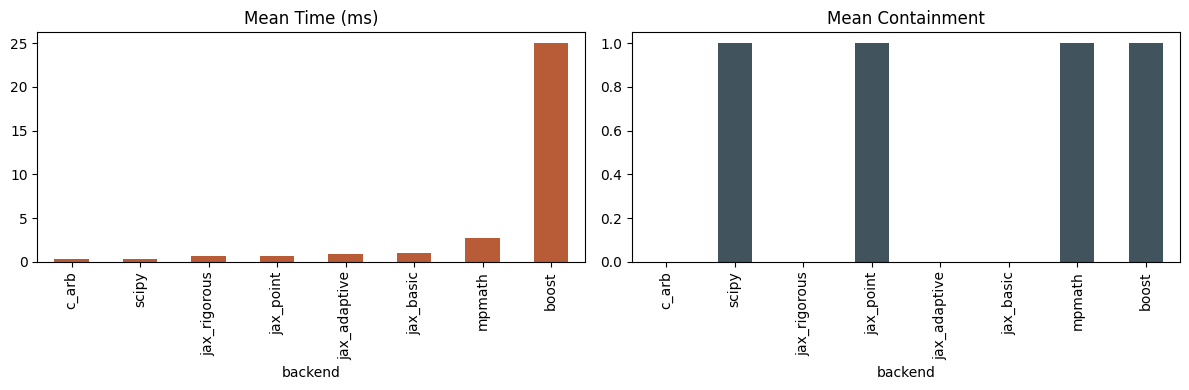

In [13]:
plot_df = profile_df.copy()
for col in ['time_ms', 'containment_rate', 'mean_abs_err']:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')
summary = plot_df.groupby('backend', dropna=False)[['time_ms', 'containment_rate']].mean(numeric_only=True).sort_values('time_ms')
summary.to_csv(EXAMPLE_OUTPUT_ROOT / f'profile_backend_summary_{JAX_MODE}.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary['time_ms'].plot(kind='bar', ax=axes[0], title='Mean Time (ms)', color='#b85c38')
summary['containment_rate'].plot(kind='bar', ax=axes[1], title='Mean Containment', color='#41535d')
fig.tight_layout()
fig.savefig(EXAMPLE_OUTPUT_ROOT / f'profile_backend_summary_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

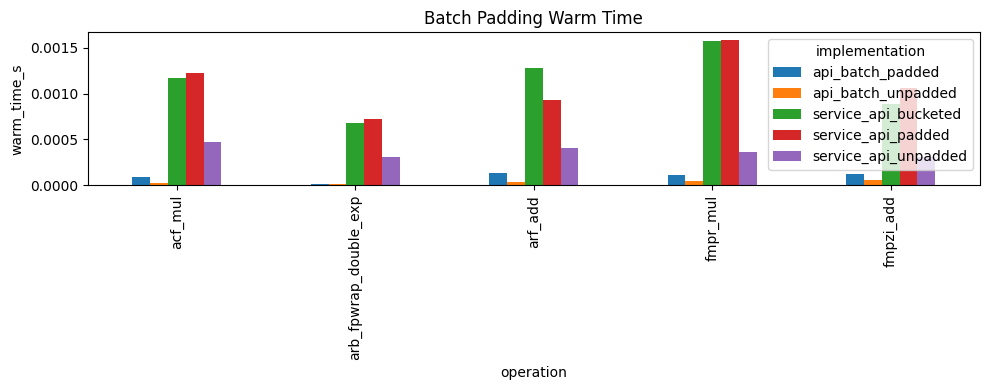

In [14]:
if not batch_padding_df.empty:
    pad_grouped = batch_padding_df.groupby(['operation', 'implementation'], as_index=False)['warm_time_s'].mean()
    pad_pivot = pad_grouped.pivot(index='operation', columns='implementation', values='warm_time_s')
    ax = pad_pivot.plot(kind='bar', figsize=(10, 4), title='Batch Padding Warm Time')
    ax.set_ylabel('warm_time_s')
    plt.tight_layout()
    plt.savefig(EXAMPLE_OUTPUT_ROOT / f'batch_padding_warm_time_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
    plt.show()

## Optional Diagnostics

Use the matrix/compile diagnostics tools only when compile traces or memory deltas are needed. The scalar tranche here keeps those optional.

In [15]:
summary_lines = [
    f'# Example Core Scalar Surface Summary ({JAX_MODE})',
    '',
    f'- python: `{PYTHON}`',
    f'- backend: `{runtime_payload["platform"]}`',
    f'- devices: `{runtime_payload["devices"]}`',
    f'- benchmark_rows: `{len(bench_df)}`',
    f'- profile_rows: `{len(profile_df)}`',
    f'- comparison_rows: `{len(comparison_rows)}`',
    f'- batch_padding_rows: `{len(batch_padding_df)}`',
    '',
    '## Benchmark Operations',
    '',
]
for op in sorted(set(bench_df['operation'].tolist())):
    summary_lines.append(f'- `{op}`')
summary_lines.extend(['', '## Backend Summary', ''])
for row in summary.reset_index().to_dict(orient='records'):
    summary_lines.append(f"- `{row['backend']}`: mean_time_ms={row['time_ms']:.6g}, mean_containment={row['containment_rate']:.6g}")
if not batch_padding_df.empty:
    summary_lines.extend(['', '## Batch Padding Speed', ''])
    for row in batch_padding_df.to_dict(orient='records'):
        summary_lines.append(f"- `{row['operation']}` / `{row['implementation']}`: warm={row['warm_time_s']:.6g}s, recompile={row['recompile_time_s']:.6g}s")
(EXAMPLE_OUTPUT_ROOT / f'summary_{JAX_MODE}.md').write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
display('\n'.join(summary_lines[:16]))

"# Example Core Scalar Surface Summary (cpu)\n\n- python: `/home/phili/miniforge3/envs/jax/bin/python`\n- backend: `cpu`\n- devices: `['TFRT_CPU_0']`\n- benchmark_rows: `42`\n- profile_rows: `288`\n- comparison_rows: `2`\n- batch_padding_rows: `37`\n\n## Benchmark Operations\n\n- `acf_mul`\n- `arb_fpwrap_double_exp`\n- `arf_add`\n- `fmpr_mul`"